In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('fifa_ranking_2022-10-06.csv')

In [52]:
df.head()

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [53]:
df.shape

(211, 7)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team             211 non-null    object 
 1   team_code        211 non-null    object 
 2   association      211 non-null    object 
 3   rank             211 non-null    int64  
 4   previous_rank    211 non-null    int64  
 5   points           211 non-null    float64
 6   previous_points  211 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.7+ KB


In [55]:
df.describe()

,rank,previous_rank,points,previous_points
count,211.00000,211.00000,211.000000,211.000000
mean,106.00000,106.00000,1220.687346,1220.645592
std,61.05462,61.05462,253.420954,253.331712
min,1.00000,1.00000,762.220000,763.820000
25%,53.50000,53.50000,1007.675000,1008.330000
50%,106.00000,106.00000,1192.090000,1183.900000
75%,158.50000,158.50000,1433.465000,1431.790000
max,211.00000,211.00000,1841.300000,1837.560000


In [56]:
df.isnull().sum()

team               0
team_code          0
association        0
rank               0
previous_rank      0
points             0
previous_points    0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.corr(numeric_only = True)

,rank,previous_rank,points,previous_points
rank,1.000000,0.999559,-0.991990,-0.991854
previous_rank,0.999559,1.000000,-0.991698,-0.992120
points,-0.991990,-0.991698,1.000000,0.999687
previous_points,-0.991854,-0.992120,0.999687,1.000000


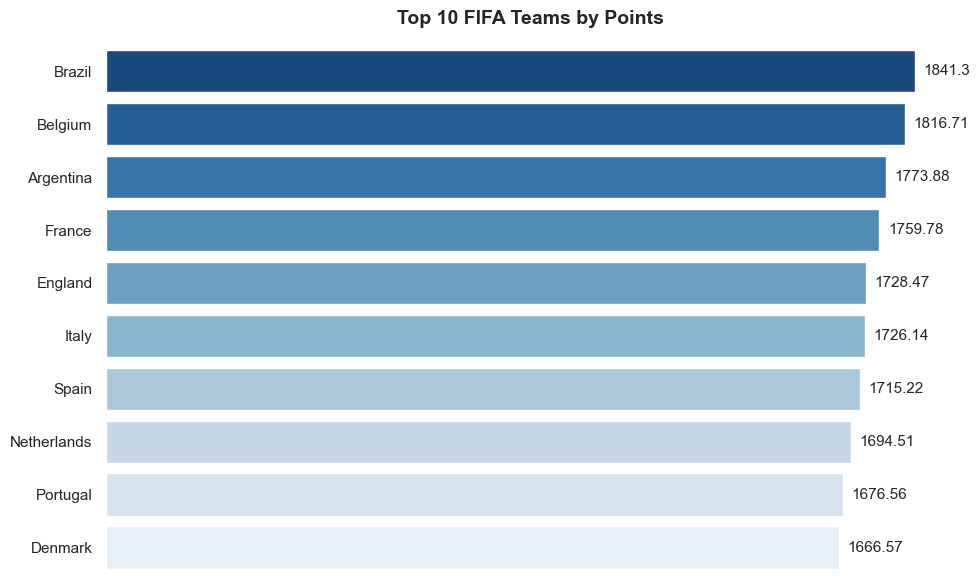

In [67]:
plt.figure(figsize=(10, 6))

top_10 = df.nlargest(10, 'points')

ax = sns.barplot(x='points', y='team', data=top_10, palette='Blues_r', hue='team', legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=6, fontsize=11)
    
sns.despine(left=True, bottom=True, top=True, right=True)

plt.title('Top 10 FIFA Teams by Points', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('') 
plt.ylabel('')   
ax.set_xticks([])
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [61]:
df['association'].unique()

array(['CONMEBOL', 'UEFA', 'CONCACAF', 'CAF', 'AFC', 'OFC'], dtype=object)

C:\Users\user\AppData\Local\Temp\ipykernel_17516\2337148091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='association', data=df, order=df['association'].value_counts().index, palette='viridis')


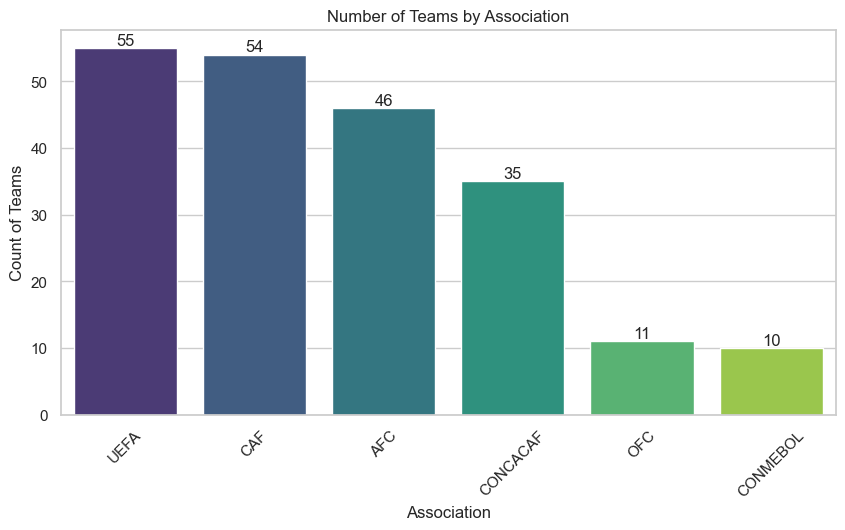

In [69]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(x='association', data=df, order=df['association'].value_counts().index, palette='viridis')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Teams by Association')
plt.xlabel('Association')
plt.ylabel('Count of Teams')
plt.xticks(rotation=45)
plt.show()

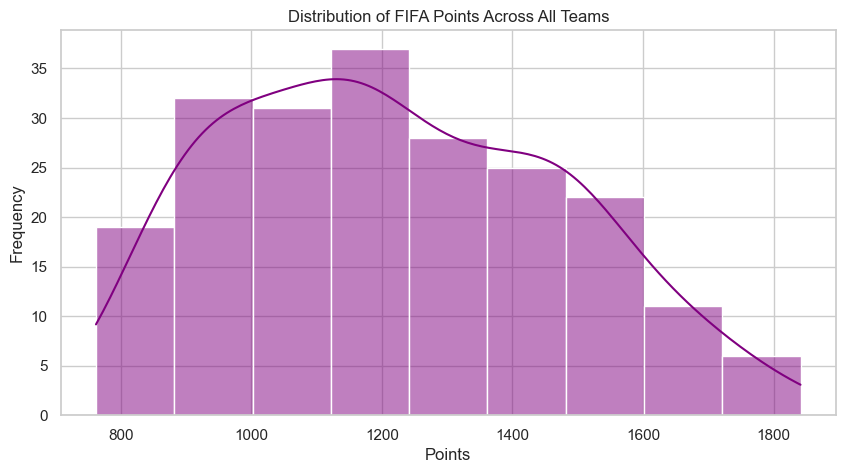

In [70]:
plt.figure(figsize=(10, 5))
sns.histplot(df['points'], kde=True, color='purple')
plt.title('Distribution of FIFA Points Across All Teams')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.show()

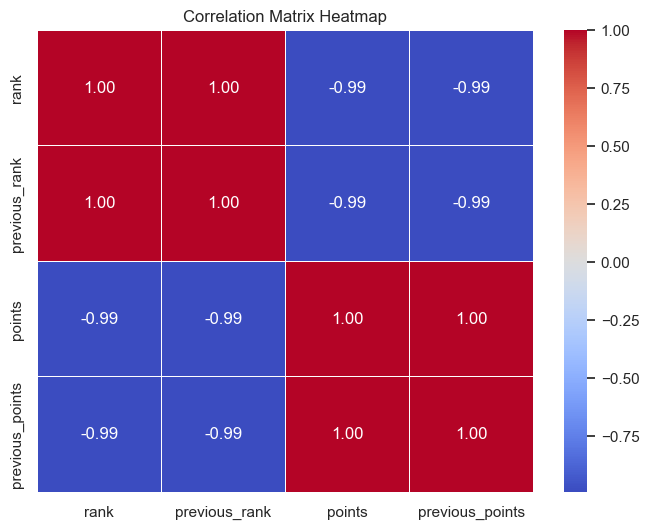

In [71]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()